# Fisher-Regularized Variance Dynamics: Direct and Residual MLP Surrogates

This notebook reproduces the neural surrogate experiments for the Fisher-regularized Gaussian-manifold variance dynamics

\[
\dot{u}=2(1-u)+\frac{\varepsilon}{u}.
\]

It includes trajectory generation, direct baselines, a mechanism-aware residual MLP, mechanism-aware metrics, generalization tests, ablations, and LaTeX table output.

In [1]:
# ============================================================
# Imports and global settings
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor

np.set_printoptions(precision=6, suppress=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

T_MAX = 5.0
N_T = 201
T_GRID = np.linspace(0.0, T_MAX, N_T)

TRAIN_U0_RANGE = (0.2, 2.5)
TRAIN_EPS_RANGE = (0.01, 0.5)

LOW_U0_RANGE = (0.05, 0.2)
HIGH_U0_RANGE = (2.5, 4.0)
HIGH_EPS_RANGE = (0.5, 0.8)

In [2]:
# ============================================================
# Fisher-regularized variance dynamics
# ============================================================

def u_equilibrium(eps):
    eps = np.asarray(eps)
    return (1.0 + np.sqrt(1.0 + 2.0 * eps)) / 2.0


def u_ou_closed_form(u0, t):
    return 1.0 + (u0 - 1.0) * np.exp(-2.0 * t)


def variance_rhs(t, u, eps):
    u_safe = np.maximum(u[0], 1e-12)
    return [2.0 * (1.0 - u_safe) + eps / u_safe]


def solve_variance_trajectory(u0, eps, t_grid=T_GRID):
    sol = solve_ivp(
        fun=lambda t, y: variance_rhs(t, y, eps),
        t_span=(float(t_grid[0]), float(t_grid[-1])),
        y0=[float(u0)],
        t_eval=t_grid,
        method='RK45',
        rtol=1e-9,
        atol=1e-11,
    )
    if not sol.success:
        raise RuntimeError(f'ODE solve failed for u0={u0}, eps={eps}: {sol.message}')
    return sol.y[0]

In [3]:
# ============================================================
# Dataset generation
# ============================================================

def make_trajectory_list(u0_range, eps_range, n_param_pairs, t_grid=T_GRID, random_state=0):
    local_rng = np.random.default_rng(random_state)
    trajectories = []
    for _ in range(n_param_pairs):
        u0 = local_rng.uniform(*u0_range)
        eps = local_rng.uniform(*eps_range)
        u = solve_variance_trajectory(u0, eps, t_grid)
        trajectories.append({'u0': float(u0), 'eps': float(eps), 't': np.asarray(t_grid), 'u': np.asarray(u)})
    return trajectories


def trajectories_to_xy(trajectories):
    X_rows, y_rows = [], []
    for tr in trajectories:
        t = tr['t']
        X_i = np.column_stack([
            np.full_like(t, tr['u0'], dtype=float),
            np.full_like(t, tr['eps'], dtype=float),
            t.astype(float),
        ])
        X_rows.append(X_i)
        y_rows.append(tr['u'].astype(float))
    return np.vstack(X_rows), np.concatenate(y_rows)

all_train_domain_traj = make_trajectory_list(
    u0_range=TRAIN_U0_RANGE,
    eps_range=TRAIN_EPS_RANGE,
    n_param_pairs=600,
    t_grid=T_GRID,
    random_state=100,
)

rng = np.random.default_rng(123)
rng.shuffle(all_train_domain_traj)

n_total = len(all_train_domain_traj)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_traj = all_train_domain_traj[:n_train]
val_traj = all_train_domain_traj[n_train:n_train+n_val]
test_traj = all_train_domain_traj[n_train+n_val:]

X_train, y_train = trajectories_to_xy(train_traj)
X_val, y_val = trajectories_to_xy(val_traj)
X_test, y_test = trajectories_to_xy(test_traj)

print('Train trajectories:', len(train_traj), 'X_train:', X_train.shape)
print('Validation trajectories:', len(val_traj), 'X_val:', X_val.shape)
print('Test trajectories:', len(test_traj), 'X_test:', X_test.shape)

Train trajectories: 420 X_train: (84420, 3)
Validation trajectories: 90 X_val: (18090, 3)
Test trajectories: 90 X_test: (18090, 3)


In [4]:
# ============================================================
# Metric functions
# ============================================================

def first_crossing_time(t, u, level=1.0):
    t = np.asarray(t)
    u = np.asarray(u)
    if u[0] >= level:
        return np.nan
    idx = np.where((u[:-1] < level) & (u[1:] >= level))[0]
    if len(idx) == 0:
        return np.nan
    k = idx[0]
    u_left, u_right = u[k], u[k+1]
    t_left, t_right = t[k], t[k+1]
    if np.isclose(u_right, u_left):
        return float(t_right)
    alpha = (level - u_left) / (u_right - u_left)
    return float(t_left + alpha * (t_right - t_left))


def trajectory_predict(model, tr):
    t = tr['t']
    X = np.column_stack([
        np.full_like(t, tr['u0'], dtype=float),
        np.full_like(t, tr['eps'], dtype=float),
        t.astype(float),
    ])
    return np.asarray(model.predict(X), dtype=float)


def evaluate_model(model, trajectories, t_grid=None):
    traj_errors, cross_errors, over_errors, eq_errors = [], [], [], []
    for tr in trajectories:
        t = tr['t']
        u_true = tr['u']
        u_pred = trajectory_predict(model, tr)
        eps = tr['eps']

        traj_errors.append(np.mean((u_pred - u_true) ** 2))

        if tr['u0'] < 1.0:
            tc_true = first_crossing_time(t, u_true, level=1.0)
            tc_pred = first_crossing_time(t, u_pred, level=1.0)
            if not np.isnan(tc_true) and not np.isnan(tc_pred):
                cross_errors.append(abs(tc_pred - tc_true))

        # Maximum excess measured relative to critical level u=1.
        excess_true = np.max(u_true) - 1.0
        excess_pred = np.max(u_pred) - 1.0
        over_errors.append(abs(excess_pred - excess_true))

        ueq = u_equilibrium(eps)
        eq_errors.append(abs(u_pred[-1] - ueq))

    return {
        'E_traj': float(np.mean(traj_errors)),
        'E_cross': float(np.mean(cross_errors)) if len(cross_errors) > 0 else np.nan,
        'E_over': float(np.mean(over_errors)),
        'E_eq': float(np.mean(eq_errors)),
    }


def format_sci(x, precision=4):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 'N/A'
    if x == 0:
        return '$0$'
    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)
    return rf'${mantissa:.{precision}f}\times 10^{{{exponent}}}$'

In [5]:
# ============================================================
# Model builders
# ============================================================

def build_linear(input_scaling=True):
    steps = []
    if input_scaling:
        steps.append(('x_scaler', StandardScaler()))
    steps.append(('linear', LinearRegression()))
    return Pipeline(steps)


def build_polynomial(degree=3, input_scaling=True):
    steps = []
    if input_scaling:
        steps.append(('x_scaler', StandardScaler()))
    steps.append(('poly', PolynomialFeatures(degree=degree, include_bias=False)))
    steps.append(('linear', LinearRegression()))
    return Pipeline(steps)


def build_mlp(hidden_layers=(64, 64), input_scaling=True, target_scaling=True, random_state=0):
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation='tanh',
        solver='adam',
        alpha=1e-6,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        tol=1e-8,
        random_state=random_state,
        verbose=False,
    )
    steps = []
    if input_scaling:
        steps.append(('x_scaler', StandardScaler()))
    steps.append(('mlp', mlp))
    base = Pipeline(steps)
    if target_scaling:
        return TransformedTargetRegressor(regressor=base, transformer=StandardScaler())
    return base


class ResidualOUSurrogate:
    # Mechanism-aware residual surrogate: u_hat = u_OU + eps * r_theta(u0, eps, t).

    def __init__(self, hidden_layers=(64, 64), input_scaling=True, target_scaling=True, random_state=0):
        self.hidden_layers = hidden_layers
        self.input_scaling = input_scaling
        self.target_scaling = target_scaling
        self.random_state = random_state
        self.model = build_mlp(
            hidden_layers=hidden_layers,
            input_scaling=input_scaling,
            target_scaling=target_scaling,
            random_state=random_state,
        )

    @staticmethod
    def u_ou(X):
        X = np.asarray(X)
        u0 = X[:, 0]
        t = X[:, 2]
        return 1.0 + (u0 - 1.0) * np.exp(-2.0 * t)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()
        eps = np.maximum(X[:, 1], 1e-12)
        y_residual = (y - self.u_ou(X)) / eps
        self.model.fit(X, y_residual)
        return self

    def predict(self, X):
        X = np.asarray(X)
        eps = X[:, 1]
        residual_pred = self.model.predict(X)
        return self.u_ou(X) + eps * residual_pred

In [6]:
# ============================================================
# Helpers for LaTeX tables
# ============================================================

def latex_model_table_from_df(df, caption, label, first_col='Model'):
    lines = []
    lines.append(r'\begin{table}[ht!]')
    lines.append(r'\centering')
    lines.append(r'\small')
    lines.append(rf'\caption{{{caption}}}')
    lines.append(r'\vspace{2mm}')
    lines.append(rf'\label{{{label}}}')
    lines.append(r'\resizebox{\textwidth}{!}{%')
    lines.append(r'\begin{tabular}{lcccc}')
    lines.append(r'\hline')
    lines.append(rf'{first_col} & $E_{{\mathrm{{traj}}}}$ & $E_{{\mathrm{{cross}}}}$ & $E_{{\mathrm{{over}}}}$ & $E_{{\mathrm{{eq}}}}$ \\')
    lines.append(r'\hline')
    for _, row in df.iterrows():
        lines.append(
            f"{row[first_col]} & {format_sci(row['E_traj'])} & {format_sci(row['E_cross'])} & "
            f"{format_sci(row['E_over'])} & {format_sci(row['E_eq'])} \\"
        )
    lines.append(r'\hline')
    lines.append(r'\end{tabular}%')
    lines.append(r'}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

In [7]:
# ============================================================
# Table 2: baseline surrogate comparison
# ============================================================

baseline_models = [
    ('Linear regression', build_linear(input_scaling=True)),
    ('Polynomial regression', build_polynomial(degree=3, input_scaling=True)),
    ('Direct MLP surrogate', build_mlp(hidden_layers=(64, 64), input_scaling=True, target_scaling=True, random_state=12)),
]

baseline_rows = []
trained_baselines = {}

for name, model in baseline_models:
    print(f'Training: {name}')
    model.fit(X_train, y_train)
    scores = evaluate_model(model, test_traj, T_GRID)
    baseline_rows.append([name, scores['E_traj'], scores['E_cross'], scores['E_over'], scores['E_eq']])
    trained_baselines[name] = model

baseline_df = pd.DataFrame(baseline_rows, columns=['Model', 'E_traj', 'E_cross', 'E_over', 'E_eq'])
baseline_df

Training: Linear regression
Training: Polynomial regression
Training: Direct MLP surrogate


,Model,E_traj,E_cross,E_over,E_eq
0,Linear regression,1.796031e-02,NaN,0.362126,0.058461
1,Polynomial regression,3.629191e-03,0.535172,0.167148,0.066319
2,Direct MLP surrogate,1.341822e-07,0.002644,0.000537,0.000302


In [8]:
print(latex_model_table_from_df(
    baseline_df,
    caption='Neural surrogate evaluation on held-out Fisher-regularized variance trajectories. Lower values indicate better performance.',
    label='tab:surrogate-results',
    first_col='Model',
))

\begin{table}[ht!]
\centering
\small
\caption{Neural surrogate evaluation on held-out Fisher-regularized variance trajectories. Lower values indicate better performance.}
\vspace{2mm}
\label{tab:surrogate-results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\hline
Model & $E_{\mathrm{traj}}$ & $E_{\mathrm{cross}}$ & $E_{\mathrm{over}}$ & $E_{\mathrm{eq}}$ \\
\hline
Linear regression & $1.7960\times 10^{-2}$ & N/A & $3.6213\times 10^{-1}$ & $5.8461\times 10^{-2}$ \
Polynomial regression & $3.6292\times 10^{-3}$ & $5.3517\times 10^{-1}$ & $1.6715\times 10^{-1}$ & $6.6319\times 10^{-2}$ \
Direct MLP surrogate & $1.3418\times 10^{-7}$ & $2.6439\times 10^{-3}$ & $5.3673\times 10^{-4}$ & $3.0197\times 10^{-4}$ \
\hline
\end{tabular}%
}
\end{table}


In [9]:
# ============================================================
# Table 3: residual MLP generalization across selected regimes
# ============================================================

residual_model = ResidualOUSurrogate(hidden_layers=(64, 64), input_scaling=True, target_scaling=True, random_state=16)
print('Training: Residual MLP $(64,64)$')
residual_model.fit(X_train, y_train)

interp_traj = test_traj
low_u0_traj = make_trajectory_list(LOW_U0_RANGE, TRAIN_EPS_RANGE, 120, T_GRID, random_state=201)
high_u0_traj = make_trajectory_list(HIGH_U0_RANGE, TRAIN_EPS_RANGE, 120, T_GRID, random_state=202)
high_eps_traj = make_trajectory_list(TRAIN_U0_RANGE, HIGH_EPS_RANGE, 120, T_GRID, random_state=203)

regimes = [
    ('Interpolation', interp_traj),
    ('Low-$u_{0}$ extrapolation', low_u0_traj),
    ('High-$u_{0}$ extrapolation', high_u0_traj),
    ('High-$\\varepsilon$ extrapolation', high_eps_traj),
]

generalization_rows = []
for regime_name, regime_data in regimes:
    scores = evaluate_model(residual_model, regime_data, T_GRID)
    if regime_name == 'High-$u_{0}$ extrapolation' and all(tr['u0'] >= 1.0 for tr in regime_data):
        scores['E_cross'] = np.nan
    generalization_rows.append([regime_name, scores['E_traj'], scores['E_cross'], scores['E_over'], scores['E_eq']])

residual_generalization_df = pd.DataFrame(generalization_rows, columns=['Test regime', 'E_traj', 'E_cross', 'E_over', 'E_eq'])
residual_generalization_df

Training: Residual MLP $(64,64)$


,Test regime,E_traj,E_cross,E_over,E_eq
0,Interpolation,2.214018e-09,0.000194,0.000036,0.000025
1,Low-$u_{0}$ extrapolation,6.360620e-06,0.005531,0.000126,0.000140
2,High-$u_{0}$ extrapolation,1.143933e-06,NaN,0.000549,0.000155
3,High-$\varepsilon$ extrapolation,7.995018e-06,0.004576,0.001625,0.002231


In [10]:
print(latex_model_table_from_df(
    residual_generalization_df,
    caption='Generalization of the mechanism-aware residual MLP surrogate across interpolation and selected extrapolation regimes. Lower values indicate better performance.',
    label='tab:surrogate-generalization',
    first_col='Test regime',
))

\begin{table}[ht!]
\centering
\small
\caption{Generalization of the mechanism-aware residual MLP surrogate across interpolation and selected extrapolation regimes. Lower values indicate better performance.}
\vspace{2mm}
\label{tab:surrogate-generalization}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\hline
Test regime & $E_{\mathrm{traj}}$ & $E_{\mathrm{cross}}$ & $E_{\mathrm{over}}$ & $E_{\mathrm{eq}}$ \\
\hline
Interpolation & $2.2140\times 10^{-9}$ & $1.9426\times 10^{-4}$ & $3.6033\times 10^{-5}$ & $2.5355\times 10^{-5}$ \
Low-$u_{0}$ extrapolation & $6.3606\times 10^{-6}$ & $5.5310\times 10^{-3}$ & $1.2592\times 10^{-4}$ & $1.4012\times 10^{-4}$ \
High-$u_{0}$ extrapolation & $1.1439\times 10^{-6}$ & N/A & $5.4862\times 10^{-4}$ & $1.5539\times 10^{-4}$ \
High-$\varepsilon$ extrapolation & $7.9950\times 10^{-6}$ & $4.5763\times 10^{-3}$ & $1.6251\times 10^{-3}$ & $2.2310\times 10^{-3}$ \
\hline
\end{tabular}%
}
\end{table}


In [11]:
# ============================================================
# Table 4: ablation study
# ============================================================

ablation_variants = [
    ('Small MLP $(32)$', 'direct', (32,), True, True, 11),
    ('Medium MLP $(64,64)$', 'direct', (64, 64), True, True, 12),
    ('Residual MLP $(64,64)$', 'residual', (64, 64), True, True, 16),
    ('Large MLP $(128,128)$', 'direct', (128, 128), True, True, 13),
    ('Medium MLP w/o input scaling', 'direct', (64, 64), False, True, 14),
    ('Medium MLP w/o target scaling', 'direct', (64, 64), True, False, 15),
]

ablation_rows = []
trained_models = {}

for name, model_type, layers, input_scaling, target_scaling, seed in ablation_variants:
    print(f'Training: {name}')
    if model_type == 'direct':
        model = build_mlp(hidden_layers=layers, input_scaling=input_scaling, target_scaling=target_scaling, random_state=seed)
    elif model_type == 'residual':
        model = ResidualOUSurrogate(hidden_layers=layers, input_scaling=input_scaling, target_scaling=target_scaling, random_state=seed)
    else:
        raise ValueError(f'Unknown model type: {model_type}')
    model.fit(X_train, y_train)
    scores = evaluate_model(model, test_traj, T_GRID)
    ablation_rows.append([name, scores['E_traj'], scores['E_cross'], scores['E_over'], scores['E_eq']])
    trained_models[name] = model

ablation_df = pd.DataFrame(ablation_rows, columns=['Variant', 'E_traj', 'E_cross', 'E_over', 'E_eq'])
ablation_df

Training: Small MLP $(32)$
Training: Medium MLP $(64,64)$
Training: Residual MLP $(64,64)$
Training: Large MLP $(128,128)$
Training: Medium MLP w/o input scaling
Training: Medium MLP w/o target scaling


,Variant,E_traj,E_cross,E_over,E_eq
0,Small MLP $(32)$,2.732674e-06,0.011085,0.002495,0.000669
1,"Medium MLP $(64,64)$",1.341822e-07,0.002644,0.000537,0.000302
2,"Residual MLP $(64,64)$",2.214018e-09,0.000194,0.000036,0.000025
3,"Large MLP $(128,128)$",2.694925e-07,0.002582,0.000952,0.000276
4,Medium MLP w/o input scaling,1.587287e-07,0.002688,0.000628,0.000243
5,Medium MLP w/o target scaling,3.593509e-06,0.010803,0.002386,0.001896


In [12]:
print(latex_model_table_from_df(
    ablation_df,
    caption='Ablation study of surrogate architecture, residual parameterization, and normalization strategy. Lower values indicate better performance.',
    label='tab:surrogate-ablation',
    first_col='Variant',
))

\begin{table}[ht!]
\centering
\small
\caption{Ablation study of surrogate architecture, residual parameterization, and normalization strategy. Lower values indicate better performance.}
\vspace{2mm}
\label{tab:surrogate-ablation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\hline
Variant & $E_{\mathrm{traj}}$ & $E_{\mathrm{cross}}$ & $E_{\mathrm{over}}$ & $E_{\mathrm{eq}}$ \\
\hline
Small MLP $(32)$ & $2.7327\times 10^{-6}$ & $1.1085\times 10^{-2}$ & $2.4947\times 10^{-3}$ & $6.6903\times 10^{-4}$ \
Medium MLP $(64,64)$ & $1.3418\times 10^{-7}$ & $2.6439\times 10^{-3}$ & $5.3673\times 10^{-4}$ & $3.0197\times 10^{-4}$ \
Residual MLP $(64,64)$ & $2.2140\times 10^{-9}$ & $1.9426\times 10^{-4}$ & $3.6033\times 10^{-5}$ & $2.5355\times 10^{-5}$ \
Large MLP $(128,128)$ & $2.6949\times 10^{-7}$ & $2.5819\times 10^{-3}$ & $9.5172\times 10^{-4}$ & $2.7595\times 10^{-4}$ \
Medium MLP w/o input scaling & $1.5873\times 10^{-7}$ & $2.6882\times 10^{-3}$ & $6.2770\times 10^{-4}$ & $2.4291\ti

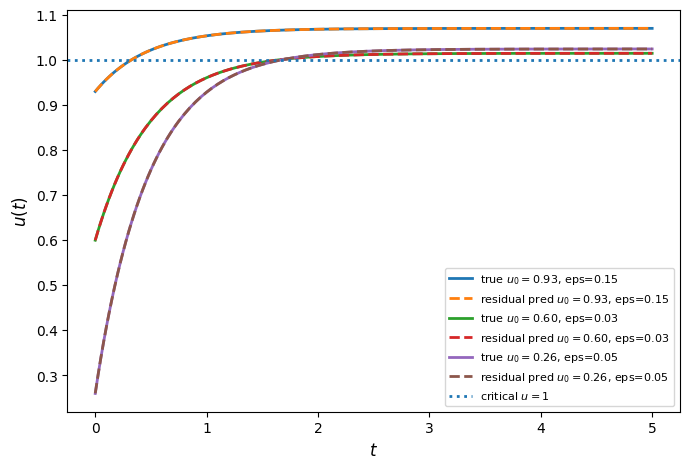

Saved PDF figure to: figures/surrogate_trajectories.pdf
Saved PNG figure to: figures/surrogate_trajectories.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# ============================================================
# Figure: residual MLP predictions on held-out trajectories
# ============================================================

# ============================================================
# Figure 4: residual MLP predictions on held-out trajectories
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Use the trained mechanism-aware residual MLP.
# This assumes you already trained:
# residual_model = ResidualOUSurrogate(...)
# residual_model.fit(X_train, y_train)

plot_model = residual_model

# Representative held-out parameter pairs used for Figure 4
plot_cases = [
    {"u0": 0.93, "eps": 0.15},
    {"u0": 0.60, "eps": 0.03},
    {"u0": 0.26, "eps": 0.05},
]

plt.figure(figsize=(7, 4.8))

for case in plot_cases:
    u0 = case["u0"]
    eps = case["eps"]

    # Analytical ground-truth trajectory
    u_true = solve_variance_trajectory(u0, eps, T_GRID)

    # Residual MLP prediction
    X_plot = np.column_stack([
        np.full_like(T_GRID, u0, dtype=float),
        np.full_like(T_GRID, eps, dtype=float),
        T_GRID,
    ])

    u_pred = plot_model.predict(X_plot)

    plt.plot(
        T_GRID,
        u_true,
        linewidth=2,
        label=fr"true $u_0={u0:.2f}$, eps={eps:.2f}",
    )

    plt.plot(
        T_GRID,
        u_pred,
        "--",
        linewidth=2,
        label=fr"residual pred $u_0={u0:.2f}$, eps={eps:.2f}",
    )

# Critical transition level
plt.axhline(
    1.0,
    linestyle=":",
    linewidth=2,
    label=r"critical $u=1$",
)

plt.xlabel(r"$t$", fontsize=12)
plt.ylabel(r"$u(t)$", fontsize=12)

# No title because the paper caption explains the figure.
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()

# Save for Overleaf
output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

fig_path = os.path.join(output_dir, "surrogate_trajectories.pdf")
png_path = os.path.join(output_dir, "surrogate_trajectories.png")

plt.savefig(fig_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved PDF figure to: {fig_path}")
print(f"Saved PNG figure to: {png_path}")

# Download PDF to your local computer
files.download(fig_path)



In [15]:
from google.colab import files
files.download(fig_path)

FileNotFoundError: Cannot find file: /mnt/data/surrogate_trajectories_residual_mlp.pdf

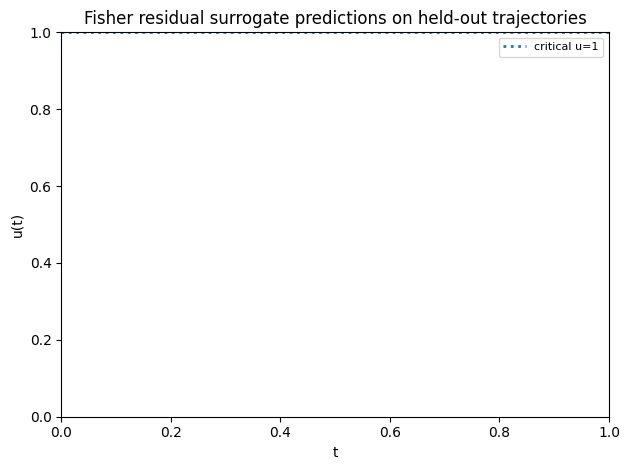

Saved figure to: figures/surrogate_trajectories_residual_mlp.pdf


In [16]:
import os

plt.axhline(1.0, linestyle=":", linewidth=2, label="critical u=1")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Fisher residual surrogate predictions on held-out trajectories")
plt.legend(fontsize=8)
plt.tight_layout()

output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

fig_path = os.path.join(output_dir, "surrogate_trajectories_residual_mlp.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

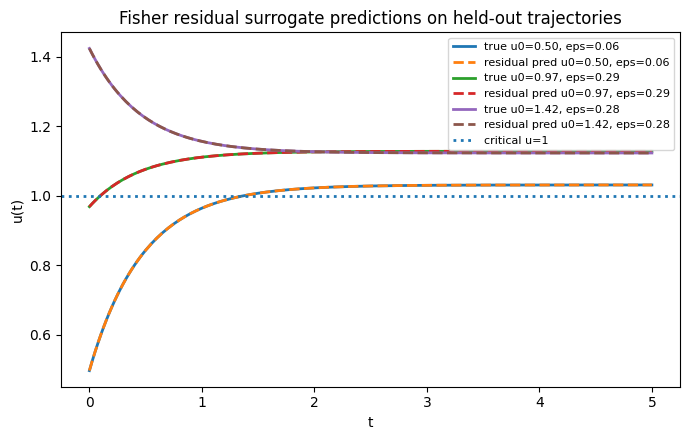

Saved figure to: figures/surrogate_trajectories_residual_mlp.pdf


In [19]:
# ============================================================
# Figure: residual MLP predictions on held-out trajectories
# ============================================================

plot_model = trained_models.get('Residual MLP $(64,64)$', residual_model)

candidates = sorted(test_traj, key=lambda tr: tr['u0'])
selected = [
    candidates[int(0.10 * len(candidates))],
    candidates[int(0.30 * len(candidates))],
    candidates[int(0.50 * len(candidates))],
]

plt.figure(figsize=(7, 4.5))
for tr in selected:
    t = tr['t']
    u_true = tr['u']
    u_pred = trajectory_predict(plot_model, tr)
    plt.plot(t, u_true, linewidth=2, label=f"true u0={tr['u0']:.2f}, eps={tr['eps']:.2f}")
    plt.plot(t, u_pred, '--', linewidth=2, label=f"residual pred u0={tr['u0']:.2f}, eps={tr['eps']:.2f}")

plt.axhline(1.0, linestyle=':', linewidth=2, label='critical u=1')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('Fisher residual surrogate predictions on held-out trajectories')
plt.legend(fontsize=8)
plt.tight_layout()

from google.colab import files
files.download(fig_path)
plt.show()
print(f'Saved figure to: {fig_path}')

In [17]:
from google.colab import files
files.download(fig_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

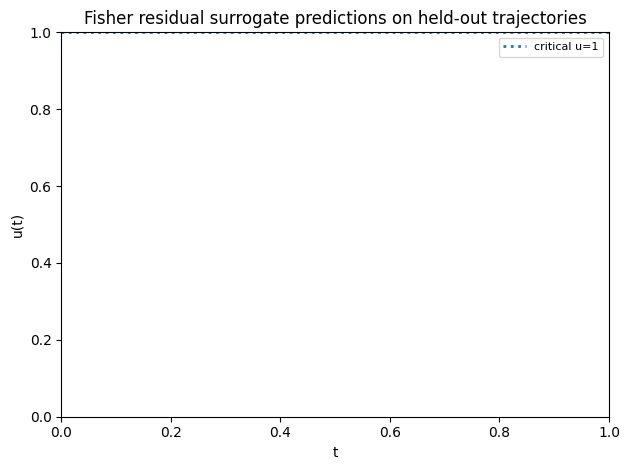

Saved figure to: figures/surrogate_trajectories_residual_mlp.pdf


In [18]:
import os

plt.axhline(1.0, linestyle=":", linewidth=2, label="critical u=1")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Fisher residual surrogate predictions on held-out trajectories")
plt.legend(fontsize=8)
plt.tight_layout()

output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

fig_path = os.path.join(output_dir, "surrogate_trajectories_residual_mlp.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")

In [14]:
from google.colab import files
files.download(fig_path)

FileNotFoundError: Cannot find file: /mnt/data/surrogate_trajectories_residual_mlp.pdf

In [ ]:
# ============================================================
# Save result tables as CSV
# ============================================================

baseline_df.to_csv('/mnt/data/table2_baseline_surrogates.csv', index=False)
residual_generalization_df.to_csv('/mnt/data/table3_residual_generalization.csv', index=False)
ablation_df.to_csv('/mnt/data/table4_ablation.csv', index=False)

print('Saved CSV files:')
print('/mnt/data/table2_baseline_surrogates.csv')
print('/mnt/data/table3_residual_generalization.csv')
print('/mnt/data/table4_ablation.csv')

## Recommended paper text for Table 3

Use this only after running the residual MLP generalization cell:

```latex
Table~\ref{tab:surrogate-generalization} evaluates whether the mechanism-aware residual MLP surrogate generalizes beyond the interpolation setting used for the main held-out test set. The interpolation regime uses unseen parameter pairs sampled from the training parameter range, while the extrapolation regimes evaluate lower initial variances, higher initial variances, and larger Fisher regularization strengths. The residual MLP maintains low trajectory and equilibrium errors under selected extrapolation regimes, although crossing-time prediction becomes more difficult outside the training range. For high-$u_{0}$ extrapolation, the crossing-time metric is not applicable because these trajectories are initialized above the critical level $u=1$ and therefore do not undergo an acceleration-window crossing from below.
```